In [1]:
import pandas as pd
import numpy as np
import ast
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ──────────────────────────────────────────
# 1. LOAD DATA
# ──────────────────────────────────────────
df = pd.read_csv("movies_metadata.csv")  # 🔁 Replace with your actual filename
print(f"Dataset shape: {df.shape}")
print(df.head(2))

C:\Users\USER\AppData\Local\Temp\ipykernel_12788\2532160565.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("movies_metadata.csv")  # 🔁 Replace with your actual filename


Dataset shape: (45466, 24)
   adult                              belongs_to_collection    budget  \
0  False  {'id': 10194, 'name': 'Toy Story Collection', ...  30000000   
1  False                                                NaN  65000000   

                                              genres  \
0  [{'id': 16, 'name': 'Animation'}, {'id': 35, '...   
1  [{'id': 12, 'name': 'Adventure'}, {'id': 14, '...   

                               homepage    id    imdb_id original_language  \
0  http://toystory.disney.com/toy-story   862  tt0114709                en   
1                                   NaN  8844  tt0113497                en   

  original_title                                           overview  ...  \
0      Toy Story  Led by Woody, Andy's toys live happily in his ...  ...   
1        Jumanji  When siblings Judy and Peter discover an encha...  ...   

  release_date      revenue runtime  \
0   1995-10-30  373554033.0    81.0   
1   1995-12-15  262797249.0   104.0   

  

In [4]:
# ──────────────────────────────────────────
# 2. CREATE TARGET: high (1) vs low (0)
# ──────────────────────────────────────────
THRESHOLD = 7.0  # Change if needed

df = df[df['vote_average'] > 0]          # Remove unrated movies
df['rating_class'] = (df['vote_average'] >= THRESHOLD).astype(int)

print(f"\nClass distribution:")
print(df['rating_class'].value_counts())
print(f"  0 = Low rated (< {THRESHOLD})")
print(f"  1 = High rated (>= {THRESHOLD})")


Class distribution:
rating_class
0    32862
1     9600
Name: count, dtype: int64
  0 = Low rated (< 7.0)
  1 = High rated (>= 7.0)


In [5]:
# ──────────────────────────────────────────
# 3. FEATURE ENGINEERING
# ──────────────────────────────────────────

# --- Numeric features ---
numeric_features = ['budget', 'popularity', 'runtime', 'revenue', 'vote_count']
df[numeric_features] = df[numeric_features].fillna(0)

# --- Genre encoding (extract first genre from JSON-like string) ---
def extract_first_genre(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return genres[0]['name'] if genres else 'Unknown'
    except:
        return 'Unknown'

df['main_genre'] = df['genres'].apply(extract_first_genre)
genre_dummies = pd.get_dummies(df['main_genre'], prefix='genre')

# --- belongs_to_collection (1 if part of collection, 0 if not) ---
df['in_collection'] = df['belongs_to_collection'].apply(
    lambda x: 0 if pd.isna(x) or x == '' else 1
)

# --- Combine all features ---
feature_cols = numeric_features + ['in_collection']
X = pd.concat([df[feature_cols], genre_dummies], axis=1)
y = df['rating_class']

print(f"\nFeatures used: {list(X.columns)}")
print(f"Total features: {X.shape[1]}")



Features used: ['budget', 'popularity', 'runtime', 'revenue', 'vote_count', 'in_collection', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_Foreign', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_Unknown', 'genre_War', 'genre_Western']
Total features: 27


In [6]:
# ──────────────────────────────────────────
# 4. TRAIN / TEST SPLIT
# ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 33969, Test size: 8493


In [7]:
# ──────────────────────────────────────────
# 5. SCALE FEATURES (critical for KNN!)
# ──────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


Best K = 18 with CV accuracy = 0.7830


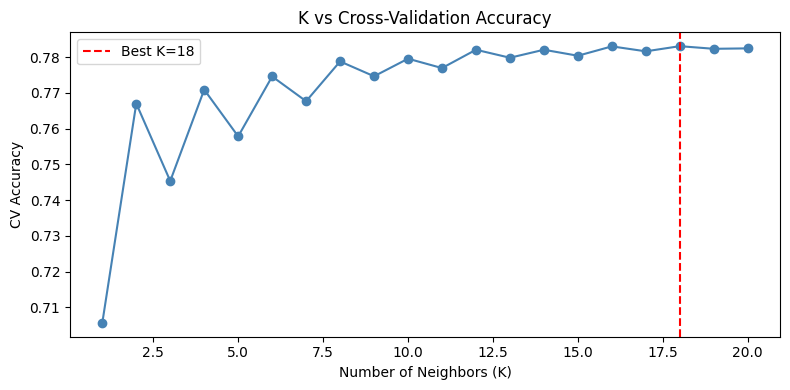

Saved: k_vs_accuracy.png


In [8]:
# ──────────────────────────────────────────
# 6. FIND BEST K
# ──────────────────────────────────────────
k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f"\nBest K = {best_k} with CV accuracy = {max(cv_scores):.4f}")

# Plot K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(k_range, cv_scores, marker='o', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title('K vs Cross-Validation Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('CV Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('k_vs_accuracy.png', dpi=150)
plt.show()
print("Saved: k_vs_accuracy.png")


In [9]:
# ──────────────────────────────────────────
# 7. TRAIN FINAL MODEL
# ──────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",18
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None



MODEL EVALUATION
Accuracy: 0.7842

Classification Report:
              precision    recall  f1-score   support

   Low rated       0.80      0.97      0.87      6573
  High rated       0.59      0.15      0.23      1920

    accuracy                           0.78      8493
   macro avg       0.69      0.56      0.55      8493
weighted avg       0.75      0.78      0.73      8493



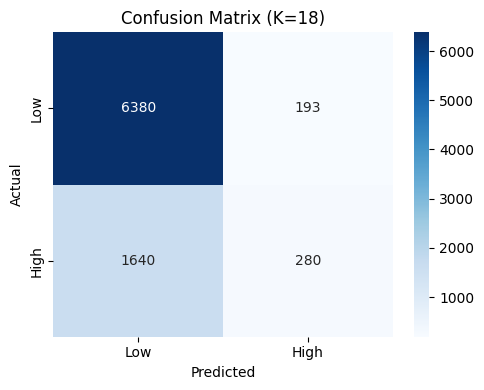

Saved: confusion_matrix.png


In [10]:
# ──────────────────────────────────────────
# 8. EVALUATE
# ──────────────────────────────────────────
y_pred = knn.predict(X_test_scaled)

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low rated', 'High rated']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'])
plt.title(f'Confusion Matrix (K={best_k})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")


In [11]:
# ──────────────────────────────────────────
# 9. PREDICT A NEW MOVIE
# ──────────────────────────────────────────
print("\n" + "="*50)
print("PREDICT A NEW MOVIE")
print("="*50)

# Example new movie — fill in real values
new_movie = pd.DataFrame([{
    'budget':     50000000,
    'popularity': 25.0,
    'runtime':    120,
    'revenue':    200000000,
    'vote_count': 3000,
    'in_collection': 1,
}])

# Add missing genre columns with 0
for col in genre_dummies.columns:
    new_movie[col] = 0
new_movie['genre_Action'] = 1   # Change to your movie's genre

new_movie_scaled = scaler.transform(new_movie[X.columns])
prediction = knn.predict(new_movie_scaled)
probability = knn.predict_proba(new_movie_scaled)

label = "HIGH rated ⭐" if prediction[0] == 1 else "LOW rated 👎"
print(f"Prediction: {label}")
print(f"Confidence: Low={probability[0][0]:.2f}, High={probability[0][1]:.2f}")


PREDICT A NEW MOVIE
Prediction: LOW rated 👎
Confidence: Low=0.78, High=0.22
